# Módulo 3 - Comparación de modelos: SVM, k-NN y Naive Bayes vs RF/GBM

## Banco Mundial - INEC - USFQ

Este lab compara tres familias de modelos de clasificación que no revisamos en detalle en el Módulo 2:

- Support Vector Machine (SVM).
- k-Nearest Neighbors (k-NN).
- Naive Bayes (NB).

Usaremos el mismo dataset simulado de hogares del curso y mantendremos RF/GBM solo como benchmark de referencia. El objetivo no es volver a desarrollar RF/GBM, sino usar lo aprendido para decidir si SVM, k-NN o NB son candidatos razonables.

## Objetivos del lab

Al final del módulo, el estudiante debería poder:

- Construir workflows de clasificación para SVM, k-NN y Naive Bayes.
- Comparar modelos nuevos contra RF/GBM usando validación cruzada.
- Interpretar curvas de validación para hiperparámetros clave.
- Interpretar curvas de aprendizaje para detectar problemas de datos, sesgo o varianza.
- Seleccionar un modelo candidato y justificarlo con métricas y estabilidad.

## 0. Paquetes y reproducibilidad

Los modelos SVM, k-NN y Naive Bayes necesitan engines adicionales dentro de `tidymodels`. Si falta alguno, ejecutar la línea de instalación comentada y reiniciar el kernel.

In [2]:
paquetes_necesarios <- c(
  "tidymodels", "tidyverse", "recipes", "parsnip", "tune", "yardstick",
  "readxl", "vip", "DALEXtra", "kernlab", "kknn",
  "naivebayes", "discrim", "ranger", "xgboost", "factoextra"
)

paquetes_faltantes <- paquetes_necesarios[!vapply(paquetes_necesarios, requireNamespace, logical(1), quietly = TRUE)]
paquetes_faltantes

# Si aparece algún paquete faltante, descomentar y ejecutar:
# install.packages(paquetes_faltantes)

suppressPackageStartupMessages({
  library(tidymodels)
  library(tidyverse)
  library(readxl)
  library(discrim)
  library(vip)
  library(DALEXtra)
  library(factoextra)
})

tidymodels_prefer()
theme_set(theme_minimal(base_size = 12))

semilla_global <- 123
set.seed(semilla_global)

output_dir <- file.path("output", "modulo3")
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

character(0)

## 1. Datos simulados del curso

Usamos el mismo dataset de hogares que en los módulos anteriores. La variable objetivo será `pobre`, con clase positiva `Pobre`.

In [3]:
hogares <- read_csv("data/hogares_modulo1.csv", show_col_types = FALSE) %>%
  mutate(
    across(c(region, area, educ_jefe, empleo_jefe, vivienda_propia, internet), as.factor),
    pobre = factor(pobre, levels = c("No pobre", "Pobre"))
  )

glimpse(hogares)

hogares %>%
  count(pobre) %>%
  mutate(prop = n / sum(n))

Rows: 1,000
Columns: 12
$ id_hogar        <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,…
$ region          <fct> Costa, Sierra, Costa, Amazonia, Amazonia, Costa, Sierr…
$ area            <fct> Urbana, Urbana, Urbana, Rural, Rural, Urbana, Rural, U…
$ miembros        <dbl> 2, 2, 2, 4, 4, 4, 4, 2, 1, 3, 6, 3, 4, 4, 9, 2, 5, 3, …
$ edad_jefe       <dbl> 35, 42, 33, 55, 62, 76, 51, 34, 60, 59, 43, 24, NA, 62…
$ educ_jefe       <fct> Secundaria, Superior, Primaria, Primaria, Secundaria, …
$ empleo_jefe     <fct> Formal, Formal, Informal, Formal, Informal, Formal, In…
$ vivienda_propia <fct> No, Sí, Sí, No, Sí, No, Sí, Sí, No, Sí, Sí, No, No, No…
$ internet        <fct> No, Sí, No, Sí, No, No, Sí, Sí, Sí, No, No, No, No, Sí…
$ transferencias  <dbl> 110.462849, 23.294594, 210.277582, 49.004129, 58.90369…
$ ingreso_pc      <dbl> 978.87, 1053.66, 450.81, 444.77, 380.50, 821.38, 663.3…
$ pobre           <fct> No pobre, No pobre, No pobre, No pobre, No pobre, No p…


pobre,n,prop
<fct>,<int>,<dbl>
No pobre,830,0.83
Pobre,170,0.17


## 2. Train/test y validación cruzada

Mantenemos la misma lógica del Módulo 2: selección de hiperparámetros con validación cruzada sobre `train` y evaluación final una sola vez sobre `test`.

In [4]:
set.seed(semilla_global)
split_hogares <- initial_split(hogares, prop = 0.80, strata = pobre)

train <- training(split_hogares)
test <- testing(split_hogares)

set.seed(semilla_global)
folds_clas <- vfold_cv(train, v = 5, strata = pobre)

metricas_clas <- metric_set(f_meas, pr_auc, roc_auc)

list(
  train = dim(train),
  test = dim(test),
  folds = length(folds_clas$splits)
)

$train
[1] 800  12

$test
[1] 200  12

$folds
[1] 5

## 3. Receta común

SVM y k-NN son sensibles a la escala de las variables, por eso la normalización es más importante aquí que en RF/GBM. Naive Bayes también se beneficia de una preparación consistente.

In [5]:
receta_clas <- recipe(
  pobre ~ region + area + miembros + edad_jefe + educ_jefe + empleo_jefe +
    vivienda_propia + internet + transferencias,
  data = train
) %>%
  step_impute_mode(all_nominal_predictors()) %>%
  step_impute_mean(all_numeric_predictors()) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_zv(all_predictors()) %>%
  step_normalize(all_numeric_predictors())

receta_clas



── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:   1
predictor: 9



── Operations 

• Mode imputation for: all_nominal_predictors()

• Mean imputation for: all_numeric_predictors()

• Dummy variables from: all_nominal_predictors()

• Zero variance filter on: all_predictors()

• Centering and scaling for: all_numeric_predictors()



## 4. Workflows: SVM, k-NN y Naive Bayes

En este módulo el foco está en estos tres modelos. RF y GBM aparecerán después solo como referencia comparativa.

En `tidymodels`, el workflow une dos piezas que siempre deben viajar juntas:

- La receta, que define cómo preparar los datos antes de entrenar.
- El modelo, que define qué algoritmo se ajusta y con qué engine.

La línea:

```r
workflow() %>% add_recipe(receta_clas) %>% add_model(modelo_svm)
```

se lee así:

- `workflow()` crea un contenedor vacío.
- `add_recipe(receta_clas)` añade el preprocesamiento común: imputación, dummies, eliminación de variables sin variación y normalización.
- `add_model(modelo_svm)` añade la especificación del modelo que se quiere entrenar.

Esto evita preparar los datos manualmente por fuera. Durante validación cruzada, `tidymodels` ajusta la receta dentro de cada fold y luego entrena el modelo correspondiente, reduciendo riesgo de fuga de información.

Los valores marcados con `tune()` no se fijan manualmente en esta celda. Se dejan como hiperparámetros para que `tune_grid()` pruebe varias combinaciones más adelante.

In [6]:
# SVM radial: cost penaliza errores; rbf_sigma controla la complejidad/localidad de la frontera.
modelo_svm <- svm_rbf(
  cost = tune(),      # mayor cost -> ajuste más estricto al entrenamiento
  rbf_sigma = tune()  # mayor sigma -> frontera más local y compleja
) %>%
  set_engine("kernlab") %>%
  set_mode("classification")

# k-NN: clasifica usando vecinos cercanos y una regla de distancia.
modelo_knn <- nearest_neighbor(
  neighbors = tune(),    # número de vecinos considerados -> mayor fit train
  weight_func = tune(),  # pondera igual o más a vecinos cercanos
  dist_power = tune()    # 1: Manhattan; 2: euclídea
) %>%
  set_engine("kknn") %>%
  set_mode("classification")

# Naive Bayes: suaviza probabilidades para evitar estimaciones extremas.
modelo_nb <- naive_Bayes(
  smoothness = tune(),  # menor-> más ajuste a datos; mayor-> más suavizado
  Laplace = tune()      # mayor Laplace: más suavizado en variables categóricas
) %>%
  set_engine("naivebayes") %>%
  set_mode("classification")

# Cada workflow combina la misma receta con un algoritmo distinto.
wf_svm <- workflow() %>% add_recipe(receta_clas) %>% add_model(modelo_svm)
wf_knn <- workflow() %>% add_recipe(receta_clas) %>% add_model(modelo_knn)
wf_nb <- workflow() %>% add_recipe(receta_clas) %>% add_model(modelo_nb)

list(SVM = wf_svm, kNN = wf_knn, NB = wf_nb)

$SVM
══ Workflow ════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: svm_rbf()

── Preprocessor ────────────────────────────────────────────────────────────────
5 Recipe Steps

• step_impute_mode()
• step_impute_mean()
• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────
Radial Basis Function Support Vector Machine Model Specification (classification)

Main Arguments:
  cost = tune()
  rbf_sigma = tune()

Computational engine: kernlab 


$kNN
══ Workflow ════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
5 Recipe Steps

• step_impute_mode()
• step_impute_mean()
• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────
K-Nearest Neighbor Model Specificatio

## 4.1 Búsqueda guiada de hiperparámetros

Usamos grillas pequeñas para que el lab sea ejecutable en clase. La tarea del estudiante es justificar si ampliaría o no estos rangos.

In [7]:
control_grid_lab <- control_grid(
  save_pred = TRUE,
  save_workflow = TRUE,
  verbose = FALSE
)

grid_svm <- tidyr::expand_grid(
  cost = c(0.1, 1, 10),
  rbf_sigma = c(0.01, 0.05, 0.10)
)

grid_knn <- tidyr::expand_grid(
  neighbors = c(3L, 7L, 15L, 25L),
  weight_func = c("rectangular", "triangular"),
  dist_power = c(1, 2)
)

grid_nb <- tidyr::expand_grid(
  smoothness = c(0.5, 1, 2),
  Laplace = c(0, 1)
)

set.seed(semilla_global)
res_svm <- tune_grid(
  wf_svm,
  resamples = folds_clas,
  grid = grid_svm,
  metrics = metricas_clas,
  control = control_grid_lab
)

set.seed(semilla_global)
res_knn <- tune_grid(
  wf_knn,
  resamples = folds_clas,
  grid = grid_knn,
  metrics = metricas_clas,
  control = control_grid_lab
)

set.seed(semilla_global)
res_nb <- tune_grid(
  wf_nb,
  resamples = folds_clas,
  grid = grid_nb,
  metrics = metricas_clas,
  control = control_grid_lab
)

In [8]:
metricas_modelos_base <- bind_rows(
  collect_metrics(res_svm) %>% mutate(modelo = "SVM"),
  collect_metrics(res_knn) %>% mutate(modelo = "k-NN"),
  collect_metrics(res_nb) %>% mutate(modelo = "Naive Bayes")
)

write_csv(metricas_modelos_base, file.path(output_dir, "metricas_svm_knn_nb_cv.csv"))

metricas_modelos_base %>%
  filter(.metric == "pr_auc") %>%
  group_by(modelo) %>%
  slice_max(mean, n = 3, with_ties = FALSE) %>%
  ungroup() %>%
  arrange(desc(mean))

cost,rbf_sigma,.metric,.estimator,mean,n,std_err,.config,modelo,neighbors,weight_func,dist_power,smoothness,Laplace
<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>
10.0,0.01,pr_auc,binary,0.9880234,5,0.002156400,pre0_mod7_post0,SVM,NA,NA,NA,NA,NA
0.1,0.01,pr_auc,binary,0.9875593,5,0.002015105,pre0_mod1_post0,SVM,NA,NA,NA,NA,NA
1.0,0.01,pr_auc,binary,0.9875484,5,0.001995146,pre0_mod4_post0,SVM,NA,NA,NA,NA,NA
NA,NA,pr_auc,binary,0.9810025,5,0.002094284,pre0_mod5_post0,Naive Bayes,NA,NA,NA,2,0
NA,NA,pr_auc,binary,0.9810025,5,0.002094284,pre0_mod6_post0,Naive Bayes,NA,NA,NA,2,1
NA,NA,pr_auc,binary,0.9792803,5,0.002613952,pre0_mod3_post0,Naive Bayes,NA,NA,NA,1,0
NA,NA,pr_auc,binary,0.9769271,5,0.005202592,pre0_mod16_post0,k-NN,25,triangular,2,NA,NA
NA,NA,pr_auc,binary,0.9767443,5,0.005069230,pre0_mod15_post0,k-NN,25,triangular,1,NA,NA
NA,NA,pr_auc,binary,0.9763398,5,0.004940086,pre0_mod12_post0,k-NN,15,triangular,2,NA,NA


## 4.2 Benchmarks RF/GBM

RF y GBM ya fueron trabajados en el Módulo 2. Aquí usamos una versión compacta solo para tener una referencia contra la cual comparar SVM, k-NN y NB.

In [9]:
modelo_rf_ref <- rand_forest(
  mtry = tune(),
  trees = 500,
  min_n = tune()
) %>%
  set_engine("ranger", importance = "impurity", probability = TRUE) %>%
  set_mode("classification")

modelo_gbm_ref <- boost_tree(
  trees = 500,
  tree_depth = tune(),
  learn_rate = tune(),
  loss_reduction = tune(),
  sample_size = tune(),
  mtry = tune(),
  min_n = tune()
) %>%
  set_engine("xgboost") %>%
  set_mode("classification")

wf_rf_ref <- workflow() %>% add_recipe(receta_clas) %>% add_model(modelo_rf_ref)
wf_gbm_ref <- workflow() %>% add_recipe(receta_clas) %>% add_model(modelo_gbm_ref)

grid_rf_ref <- tidyr::expand_grid(
  mtry = c(3L, 7L, 11L),
  min_n = c(5L, 15L)
)

grid_gbm_ref <- tidyr::expand_grid(
  tree_depth = c(1L, 3L),
  learn_rate = c(0.03, 0.08),
  loss_reduction = c(1e-10, 0.01),
  sample_size = c(0.70, 0.90),
  mtry = c(3L, 7L),
  min_n = c(5L, 15L)
)

set.seed(semilla_global)
res_rf_ref <- tune_grid(
  wf_rf_ref,
  resamples = folds_clas,
  grid = grid_rf_ref,
  metrics = metricas_clas,
  control = control_grid_lab
)

set.seed(semilla_global)
res_gbm_ref <- tune_grid(
  wf_gbm_ref,
  resamples = folds_clas,
  grid = grid_gbm_ref,
  metrics = metricas_clas,
  control = control_grid_lab
)

## 5. Comparación guiada de modelos

Comparamos el mejor resultado de validación cruzada por modelo. El criterio principal será `pr_auc`, pero los estudiantes deberían mirar también F1 y ROC AUC.

In [10]:
metricas_todos_cv <- bind_rows(
  metricas_modelos_base,
  collect_metrics(res_rf_ref) %>% mutate(modelo = "RF"),
  collect_metrics(res_gbm_ref) %>% mutate(modelo = "GBM")
)

mejores_cv <- metricas_todos_cv %>%
  filter(.metric %in% c("f1", "roc_auc", "pr_auc")) %>%
  group_by(modelo, .metric) %>%
  slice_max(mean, n = 1, with_ties = FALSE) %>%
  ungroup()

write_csv(mejores_cv, file.path(output_dir, "mejores_modelos_cv.csv"))

mejores_cv %>%
  filter(.metric == "pr_auc") %>%
  arrange(desc(mean))

cost,rbf_sigma,.metric,.estimator,mean,n,std_err,.config,modelo,neighbors,weight_func,dist_power,smoothness,Laplace,mtry,min_n,tree_depth,learn_rate,loss_reduction,sample_size
<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
10,0.01,pr_auc,binary,0.9880234,5,0.002156400,pre0_mod7_post0,SVM,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,pr_auc,binary,0.9871184,5,0.001966515,pre0_mod36_post0,GBM,NA,NA,NA,NA,NA,7,5,1,0.03,0.01,0.9
NA,NA,pr_auc,binary,0.9846046,5,0.003488677,pre0_mod2_post0,RF,NA,NA,NA,NA,NA,3,15,NA,NA,NA,NA
NA,NA,pr_auc,binary,0.9810025,5,0.002094284,pre0_mod5_post0,Naive Bayes,NA,NA,NA,2,0,NA,NA,NA,NA,NA,NA
NA,NA,pr_auc,binary,0.9769271,5,0.005202592,pre0_mod16_post0,k-NN,25,triangular,2,NA,NA,NA,NA,NA,NA,NA,NA


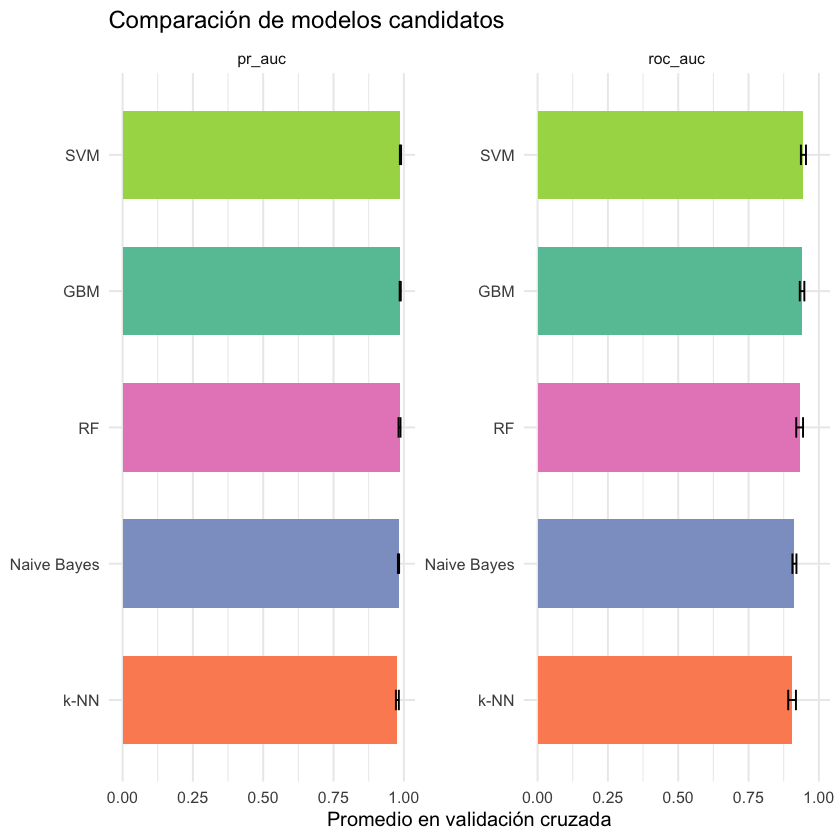

In [11]:
mejores_cv %>%
  ggplot(aes(x = reorder(modelo, mean), y = mean, fill = modelo)) +
  geom_col(show.legend = FALSE, width = 0.65) +
  geom_errorbar(aes(ymin = mean - std_err, ymax = mean + std_err), width = 0.15) +
  facet_wrap(~ .metric, scales = "free_y") +
  coord_flip() +
  scale_fill_brewer(palette = "Set2") +
  labs(
    x = NULL,
    y = "Promedio en validación cruzada",
    title = "Comparación de modelos candidatos"
  )

## 6. Curvas de validación

Una curva de validación cambia un hiperparámetro y observa cómo se mueve la métrica. Aquí se muestran ejemplos para orientar la discusión; no son la única forma de analizarlas.

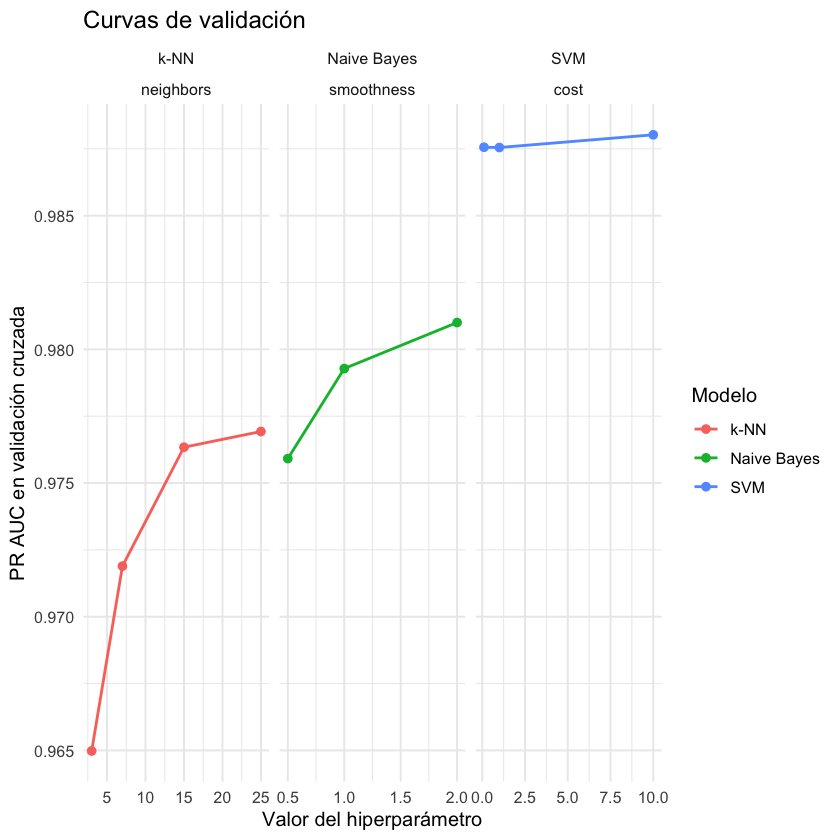

In [12]:
curva_svm_cost <- collect_metrics(res_svm) %>%
  filter(.metric == "pr_auc") %>%
  group_by(cost) %>%
  slice_max(mean, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(modelo = "SVM", parametro = "cost", valor = cost)

curva_knn_k <- collect_metrics(res_knn) %>%
  filter(.metric == "pr_auc") %>%
  group_by(neighbors) %>%
  slice_max(mean, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(modelo = "k-NN", parametro = "neighbors", valor = neighbors)

curva_nb_smooth <- collect_metrics(res_nb) %>%
  filter(.metric == "pr_auc") %>%
  group_by(smoothness) %>%
  slice_max(mean, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(modelo = "Naive Bayes", parametro = "smoothness", valor = smoothness)

curvas_validacion <- bind_rows(curva_svm_cost, curva_knn_k, curva_nb_smooth)

curvas_validacion %>%
  ggplot(aes(x = valor, y = mean, color = modelo)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  facet_wrap(modelo ~ parametro, scales = "free_x") +
  labs(
    x = "Valor del hiperparámetro",
    y = "PR AUC en validación cruzada",
    color = "Modelo",
    title = "Curvas de validación"
  )

## 7. Workflows finales

Antes de seleccionar y evaluar el modelo candidato, guardamos las mejores configuraciones encontradas y finalizamos cada workflow. Estos objetos se reutilizan en la evaluación final y en las curvas de aprendizaje.


In [13]:
mejor_svm <- select_best(res_svm, metric = "pr_auc")
mejor_knn <- select_best(res_knn, metric = "pr_auc")
mejor_nb <- select_best(res_nb, metric = "pr_auc")
mejor_rf_ref <- select_best(res_rf_ref, metric = "pr_auc")
mejor_gbm_ref <- select_best(res_gbm_ref, metric = "pr_auc")

wfs_finales <- list(
  SVM = finalize_workflow(wf_svm, mejor_svm),
  `k-NN` = finalize_workflow(wf_knn, mejor_knn),
  `Naive Bayes` = finalize_workflow(wf_nb, mejor_nb),
  RF = finalize_workflow(wf_rf_ref, mejor_rf_ref),
  GBM = finalize_workflow(wf_gbm_ref, mejor_gbm_ref)
)

## 8. Selección de modelo candidato

El estudiante debe seleccionar un modelo candidato usando evidencia de:

- Ranking de validación cruzada.
- Estabilidad (`std_err`).
- Curvas de validación.
- Complejidad e interpretabilidad.

No basta con elegir el mayor `pr_auc`: hay que justificar si la diferencia es relevante. Después de evaluar en test, las curvas de aprendizaje sirven como diagnóstico adicional para comparar validación y test.

In [14]:
modelo_candidato <- mejores_cv %>%
  filter(.metric == "pr_auc") %>%
  arrange(desc(mean), std_err) %>%
  slice(1)

modelo_candidato

cost,rbf_sigma,.metric,.estimator,mean,n,std_err,.config,modelo,neighbors,weight_func,dist_power,smoothness,Laplace,mtry,min_n,tree_depth,learn_rate,loss_reduction,sample_size
<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
10,0.01,pr_auc,binary,0.9880234,5,0.0021564,pre0_mod7_post0,SVM,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


## 9. Evaluación final en test

Una vez elegido el candidato, usamos `last_fit()` solo una vez. La celda deja una opción automática, pero en clase se puede reemplazar por la decisión argumentada del estudiante.

In [15]:
nombre_candidato <- modelo_candidato$modelo
nombre_candidato
wf_candidato <- wfs_finales[[nombre_candidato]]

set.seed(semilla_global)
fit_candidato <- last_fit(
  wf_candidato,
  split = split_hogares,
  metrics = metricas_clas
)

metricas_test_candidato <- collect_metrics(fit_candidato)
pred_test_candidato <- collect_predictions(fit_candidato)

write_csv(metricas_test_candidato, file.path(output_dir, "metricas_test_modelo_candidato.csv"))
write_csv(pred_test_candidato, file.path(output_dir, "predicciones_test_modelo_candidato.csv"))

metricas_test_candidato

pred_test_candidato %>%
  conf_mat(truth = pobre, estimate = .pred_class)

[1] "SVM"

.metric,.estimator,.estimate,.config
<chr>,<chr>,<dbl>,<chr>
f_meas,binary,0.9380531,pre0_mod0_post0
pr_auc,binary,0.9852176,pre0_mod0_post0
roc_auc,binary,0.9303685,pre0_mod0_post0


          Truth
Prediction No pobre Pobre
  No pobre      159    14
  Pobre           7    20

## 10. Curvas de aprendizaje: validación y test

Una curva de aprendizaje grafica el desempeño del modelo a medida que crece el tamaño del conjunto de entrenamiento. Sirve para diagnosticar si el problema parece venir de falta de datos o de la especificación del modelo.

La lectura central es comparar desempeño de entrenamiento y validación: una brecha grande entre ambos sugiere sobreajuste; si ambas curvas son bajas y cercanas, sugiere subajuste; si la curva de validación sigue subiendo, más datos podrían ayudar.

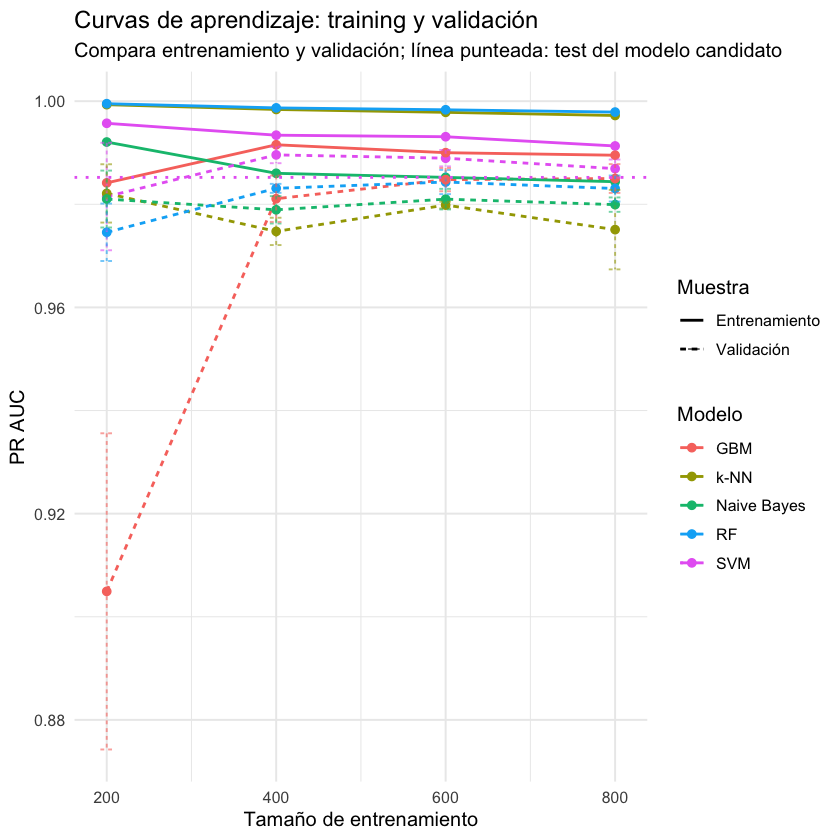

In [16]:
# Calcula un punto de la curva de aprendizaje para una fracción del train y un modelo.
calcular_punto_aprendizaje <- function(fraccion, nombre_modelo, wf_final) {
  # Cambiamos la semilla con la fracción para que cada submuestra sea reproducible.
  set.seed(semilla_global + round(fraccion * 100))

  # Tomamos una submuestra estratificada para mantener la proporción de clases.
  train_frac <- train %>%
    group_by(pobre) %>%
    slice_sample(prop = fraccion) %>%
    ungroup()

  # Validamos dentro de la submuestra para estimar desempeño fuera de entrenamiento.
  folds_frac <- vfold_cv(train_frac, v = 3, strata = pobre)
  # tidymodels nombra la probabilidad predicha como .pred_<clase>.
  prob_col_evento <- paste0(".pred_", levels(train_frac$pobre)[1])

  # Ajuste sobre la submuestra completa: mide desempeño en entrenamiento.
  ajuste_train <- fit(wf_final, data = train_frac)

  metrica_train <- predict(ajuste_train, train_frac, type = "prob") %>%
    bind_cols(train_frac %>% select(pobre)) %>%
    summarise(
      mean = pr_auc_vec(
        truth = pobre,
        estimate = .data[[prob_col_evento]],
        event_level = "first"
      ),
      std_err = NA_real_
    ) %>%
    mutate(muestra = "Entrenamiento")

  # Reajuste por folds: mide desempeño de validación para la misma fracción.
  metrica_validacion <- fit_resamples(
    wf_final,
    resamples = folds_frac,
    metrics = metricas_clas,
    control = control_resamples(save_pred = FALSE)
  ) %>%
    collect_metrics() %>%
    filter(.metric == "pr_auc") %>%
    select(mean, std_err) %>%
    mutate(muestra = "Validación")

  # Devolvemos ambos puntos con etiquetas para poder graficarlos juntos.
  bind_rows(metrica_train, metrica_validacion) %>%
    mutate(
      fraccion = fraccion,
      n_train = nrow(train_frac),
      modelo = nombre_modelo
    )
}

# Fracciones crecientes del conjunto de entrenamiento.
fracciones_train <- c(0.25, 0.50, 0.75, 1.00)

# Calculamos todas las combinaciones de fracción y modelo, y guardamos los resultados.
curvas_aprendizaje <- map_dfr(fracciones_train, function(fraccion) {
  map_dfr(names(wfs_finales), function(modelo) {
    calcular_punto_aprendizaje(fraccion, modelo, wfs_finales[[modelo]])
  })
})

# Exportamos la tabla para poder revisarla fuera del notebook.
write_csv(curvas_aprendizaje, file.path(output_dir, "curvas_aprendizaje.csv"))

# Referencia de desempeño final en test para el modelo candidato.
test_pr_auc_candidato <- metricas_test_candidato %>%
  filter(.metric == "pr_auc") %>%
  transmute(modelo = nombre_candidato, test_pr_auc = .estimate)

# Gráfico final: compara entrenamiento, validación y test del candidato.
curvas_aprendizaje %>%
  ggplot(aes(x = n_train, y = mean, color = modelo, linetype = muestra)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  geom_errorbar(
    data = curvas_aprendizaje %>% filter(muestra == "Validación"),
    aes(ymin = mean - std_err, ymax = mean + std_err),
    width = 15,
    alpha = 0.6
  ) +
  geom_hline(
    data = test_pr_auc_candidato,
    aes(yintercept = test_pr_auc, color = modelo),
    inherit.aes = FALSE,
    linetype = "dotted",
    linewidth = 0.8
  ) +
  labs(
    x = "Tamaño de entrenamiento",
    y = "PR AUC",
    color = "Modelo",
    linetype = "Muestra",
    title = "Curvas de aprendizaje: training y validación",
    subtitle = "Compara entrenamiento y validación; línea punteada: test del modelo candidato"
  )

## 11. Trabajo aplicado con datos INEC

Ahora repetir el lab con `data_pobreza_INEC.xlsx`:

- Objetivo de clasificación: `nbi_alto`.
- Excluir `canton` como predictor.
- Preparar una receta comparable a la del dataset simulado.
- Ajustar SVM, k-NN y Naive Bayes.
- Comparar contra RF/GBM solo como referencia.
- Construir al menos una curva de validación y una curva de aprendizaje.
- Seleccionar un modelo candidato y justificar la decisión.

Pista: el cambio central está en la fórmula del `recipe()` y en la variable usada para estratificar `initial_split()` y `vfold_cv()`.

In [17]:
data_inec <- suppressMessages(read_excel("data/data_pobreza_INEC.xlsx"))

inec_modelo <- data_inec %>%
  transmute(
    canton = Canton,
    nbi = NBIMEF,
    internet_inst = PorcentajeInstConInternet,
    tef_11_19 = TEF11a19madre,
    cajeros = `CajerosAutomáticosTasapobmay15años`,
    puntos_financieros = `TotPuntosAteFinTasapobmay15años`,
    pib_pc = PIBpercap,
    fecundidad = TasaGlobalFecundmadre,
    participacion_ensenanza = ParticipacionPIBEnseñanza,
    prematuro = Porcentajenacprematuromoderadomujermujermadre,
    agua_potable = aguaPotableViv,
    oficinas = `OficinasTasapobmay15años`,
    nbi_alto = factor(
      if_else(NBIMEF >= quantile(NBIMEF, probs = 0.75, na.rm = TRUE), "NBI alto", "NBI bajo"),
      levels = c("NBI bajo", "NBI alto")
    )
  )

write_csv(inec_modelo, file.path(output_dir, "inec_modelo_modulo3.csv"))

glimpse(inec_modelo)

# Trabajo del estudiante:
# 1) Crear split_inec, train_inec, test_inec y folds_inec.
# 2) Crear receta_inec_clas excluyendo canton y nbi.
# 3) Reutilizar la lógica de workflows y tuning de este lab.
# 4) Comparar, graficar y seleccionar un modelo candidato.

Rows: 221
Columns: 13
$ canton                  <chr> "CUENCA", "GIRON", "GUALACEO", "NABON", "PAUTE…
$ nbi                     <dbl> 0.1982807, 0.3311427, 0.4258015, 0.7230655, 0.…
$ internet_inst           <dbl> 68.28, 66.67, 74.47, 61.82, 67.74, 58.33, 100.…
$ tef_11_19               <dbl> 0.03, 0.09, 0.09, 0.10, 0.05, 0.08, 0.02, 0.09…
$ cajeros                 <dbl> 12, 7, 6, 4, 7, 7, 14, 10, 7, 12, 7, 5, 6, 8, …
$ puntos_financieros      <dbl> 50, 56, 42, 35, 48, 38, 57, 61, 45, 88, 35, 51…
$ pib_pc                  <dbl> 6801, 1784, 2771, 1663, 2515, 2261, 1948, 2448…
$ fecundidad              <dbl> 1.36, 1.97, 1.81, 1.52, 1.54, 1.79, 1.07, 1.87…
$ participacion_ensenanza <dbl> 5.12, 8.67, 6.49, 8.49, 6.79, 6.58, 6.77, 5.80…
$ prematuro               <dbl> 7.05, 6.74, 6.77, 5.48, 6.96, 16.95, 11.76, 5.…
$ agua_potable            <dbl> 169525, 2563, 5036, 1029, 3940, 1115, 1094, 45…
$ oficinas                <dbl> 8, 10, 10, 6, 8, 7, 18, 9, 9, 32, 8, 0, 12, 4,…
$ nbi_alto        

In [ ]:
system("conda run -n rbase jupyter nbconvert --to html modulo3.ipynb")